# SVM Comparison on Two-Moons Data

This notebook creates a complete two-moons dataset and compares:
- Linear SVM
- RBF Kernel SVM
- Polynomial Kernel SVM

It includes:
- synthetic nonlinear dataset generation
- train/test split
- standardization
- baseline comparison
- GridSearchCV hyperparameter tuning
- decision boundary visualization
- confusion matrices and classification reports


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)


## 1. Create two-moons dataset


Dataset shape: (800, 2)
Class counts: [400 400]


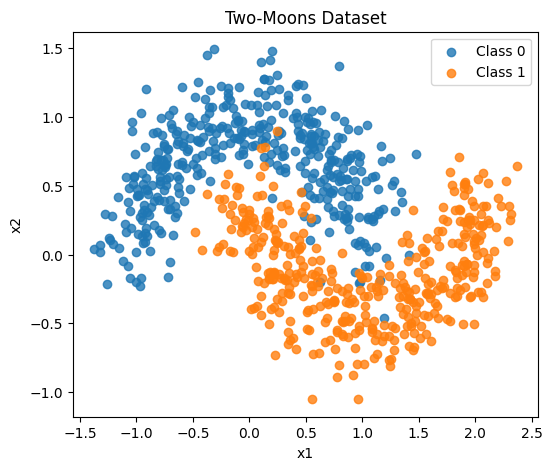

,x1,x2,target
0,1.491638,-0.124158,1
1,1.400752,-0.520636,1
2,0.858068,0.268899,0
3,0.389270,-0.605601,1
4,1.260932,0.503639,0


In [2]:
# Complete moon-shaped nonlinear dataset
X, y = make_moons(n_samples=800, noise=0.20, random_state=42)

print('Dataset shape:', X.shape)
print('Class counts:', np.bincount(y))

plt.figure(figsize=(6, 5))
plt.scatter(X[y == 0, 0], X[y == 0, 1], label='Class 0', alpha=0.8)
plt.scatter(X[y == 1, 0], X[y == 1, 1], label='Class 1', alpha=0.8)
plt.title('Two-Moons Dataset')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.show()

df = pd.DataFrame(X, columns=['x1', 'x2'])
df['target'] = y
df.head()


## 2. Train/test split


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print('Training set:', X_train.shape)
print('Test set:', X_test.shape)


Training set: (600, 2)
Test set: (200, 2)


## 3. Baseline models


In [4]:
baseline_models = {
    'Linear SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel='linear', C=1.0))
    ]),

    'RBF Kernel SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel='rbf', C=1.0, gamma='scale'))
    ]),

    'Polynomial Kernel SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel='poly', degree=3, C=1.0, gamma='scale'))
    ])
}

baseline_results = []

for name, model in baseline_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    
    baseline_results.append({
        'Model': name,
        'Test Accuracy': acc,
        'CV Mean Accuracy': cv_scores.mean(),
        'CV Std': cv_scores.std()
    })

baseline_df = pd.DataFrame(baseline_results).sort_values(by='CV Mean Accuracy', ascending=False)
baseline_df


,Model,Test Accuracy,CV Mean Accuracy,CV Std
1,RBF Kernel SVM,0.980,0.955000,0.015456
2,Polynomial Kernel SVM,0.910,0.866667,0.030277
0,Linear SVM,0.905,0.860000,0.031358


## 4. Hyperparameter search with GridSearchCV


In [5]:
search_spaces = {
    'Linear SVM': {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('svm', SVC(kernel='linear'))
        ]),
        'params': {
            'svm__C': [0.01, 0.1, 1, 10, 100]
        }
    },

    'RBF Kernel SVM': {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('svm', SVC(kernel='rbf'))
        ]),
        'params': {
            'svm__C': [0.1, 1, 10, 100],
            'svm__gamma': ['scale', 0.01, 0.1, 1, 10]
        }
    },

    'Polynomial Kernel SVM': {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('svm', SVC(kernel='poly'))
        ]),
        'params': {
            'svm__C': [0.1, 1, 10, 100],
            'svm__degree': [2, 3, 4, 5],
            'svm__gamma': ['scale', 0.01, 0.1, 1]
        }
    }
}

best_models = {}
search_summary = []

for name, config in search_spaces.items():
    print('=' * 80)
    print(f'Running GridSearchCV for: {name}')
    
    grid = GridSearchCV(
        estimator=config['pipeline'],
        param_grid=config['params'],
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )
    
    grid.fit(X_train, y_train)
    best_models[name] = grid.best_estimator_
    
    y_pred = grid.best_estimator_.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    
    print('Best parameters:', grid.best_params_)
    print(f'Best CV accuracy: {grid.best_score_:.4f}')
    print(f'Test accuracy:    {test_acc:.4f}')
    
    search_summary.append({
        'Model': name,
        'Best Params': str(grid.best_params_),
        'Best CV Accuracy': grid.best_score_,
        'Test Accuracy': test_acc
    })

search_df = pd.DataFrame(search_summary).sort_values(by='Best CV Accuracy', ascending=False)
search_df


Running GridSearchCV for: Linear SVM
Best parameters: {'svm__C': 1}
Best CV accuracy: 0.8600
Test accuracy:    0.9050
Running GridSearchCV for: RBF Kernel SVM
Best parameters: {'svm__C': 100, 'svm__gamma': 'scale'}
Best CV accuracy: 0.9717
Test accuracy:    0.9750
Running GridSearchCV for: Polynomial Kernel SVM
Best parameters: {'svm__C': 1, 'svm__degree': 5, 'svm__gamma': 1}
Best CV accuracy: 0.8817
Test accuracy:    0.9250


,Model,Best Params,Best CV Accuracy,Test Accuracy
1,RBF Kernel SVM,"{'svm__C': 100, 'svm__gamma': 'scale'}",0.971667,0.975
2,Polynomial Kernel SVM,"{'svm__C': 1, 'svm__degree': 5, 'svm__gamma': 1}",0.881667,0.925
0,Linear SVM,{'svm__C': 1},0.860000,0.905


## 5. Compare baseline vs tuned models


In [6]:
comparison_df = baseline_df[['Model', 'CV Mean Accuracy', 'Test Accuracy']].merge(
    search_df[['Model', 'Best CV Accuracy', 'Test Accuracy']],
    on='Model',
    suffixes=('_Baseline', '_Tuned')
)
comparison_df


,Model,CV Mean Accuracy,Test Accuracy_Baseline,Best CV Accuracy,Test Accuracy_Tuned
0,RBF Kernel SVM,0.955000,0.980,0.971667,0.975
1,Polynomial Kernel SVM,0.866667,0.910,0.881667,0.925
2,Linear SVM,0.860000,0.905,0.860000,0.905


## 6. Helper function to plot decision boundaries


In [7]:
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.25)
    plt.scatter(X[y == 0, 0], X[y == 0, 1], label='Class 0', edgecolors='k', alpha=0.8)
    plt.scatter(X[y == 1, 0], X[y == 1, 1], label='Class 1', marker='^', edgecolors='k', alpha=0.8)
    plt.title(title)
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.legend()
    plt.tight_layout()
    plt.show()


## 7. Visualize tuned decision boundaries


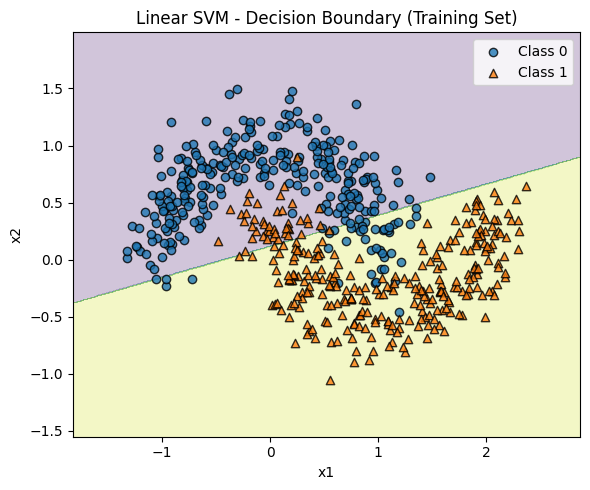

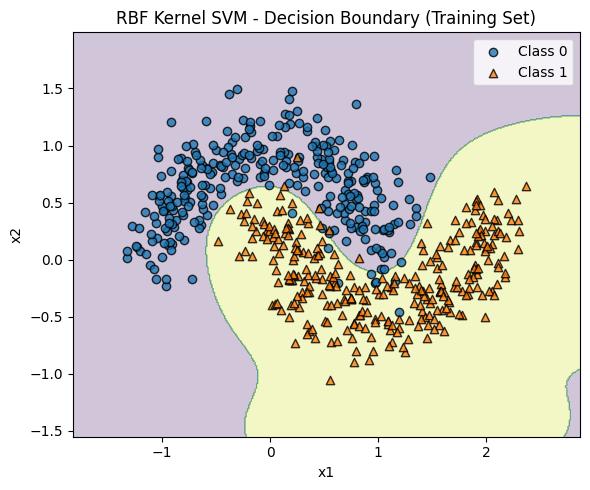

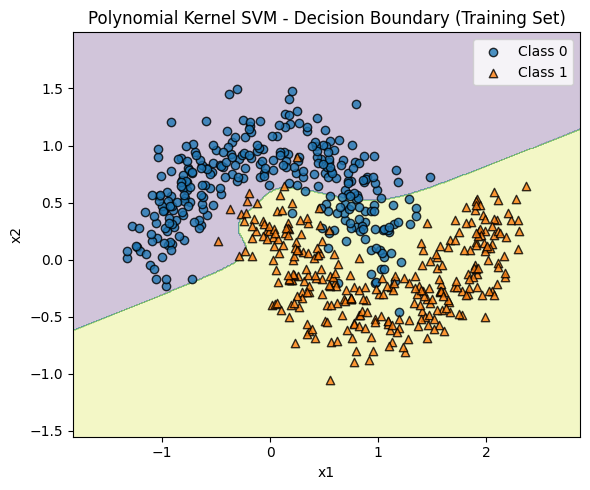

In [8]:
for name, model in best_models.items():
    model.fit(X_train, y_train)
    plot_decision_boundary(model, X_train, y_train, f'{name} - Decision Boundary (Training Set)')


## 8. Evaluate tuned models on test data


Linear SVM
Test Accuracy: 0.9050

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91       100
           1       0.94      0.87      0.90       100

    accuracy                           0.91       200
   macro avg       0.91      0.91      0.90       200
weighted avg       0.91      0.91      0.90       200



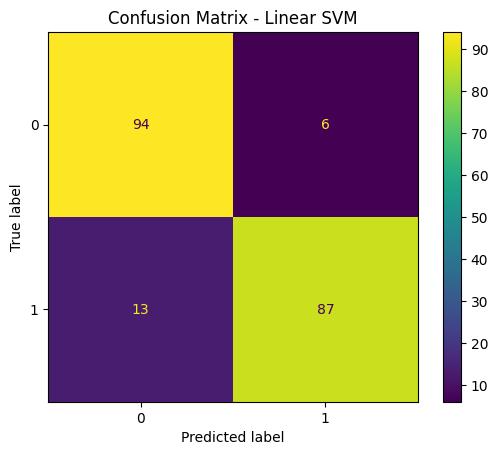

RBF Kernel SVM
Test Accuracy: 0.9750

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       100
           1       0.98      0.97      0.97       100

    accuracy                           0.97       200
   macro avg       0.98      0.97      0.97       200
weighted avg       0.98      0.97      0.97       200



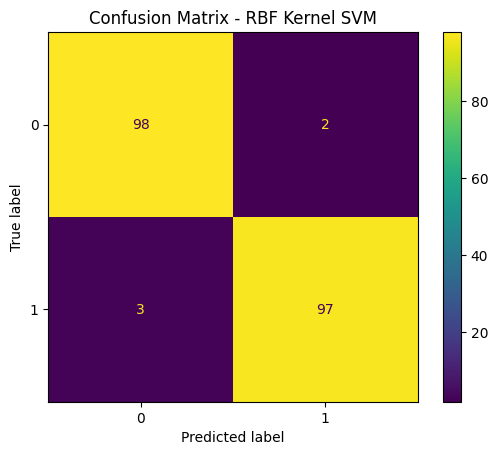

Polynomial Kernel SVM
Test Accuracy: 0.9250

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.89      0.92       100
           1       0.90      0.96      0.93       100

    accuracy                           0.93       200
   macro avg       0.93      0.93      0.92       200
weighted avg       0.93      0.93      0.92       200



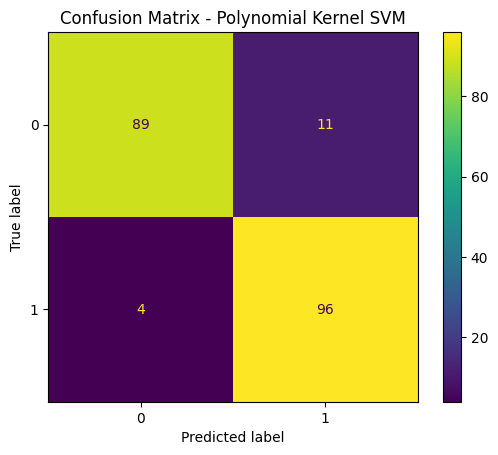

In [9]:
for name, model in best_models.items():
    print('=' * 80)
    print(name)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f'Test Accuracy: {acc:.4f}')
    print('\nClassification Report:')
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f'Confusion Matrix - {name}')
    plt.show()


## 9. Accuracy comparison chart


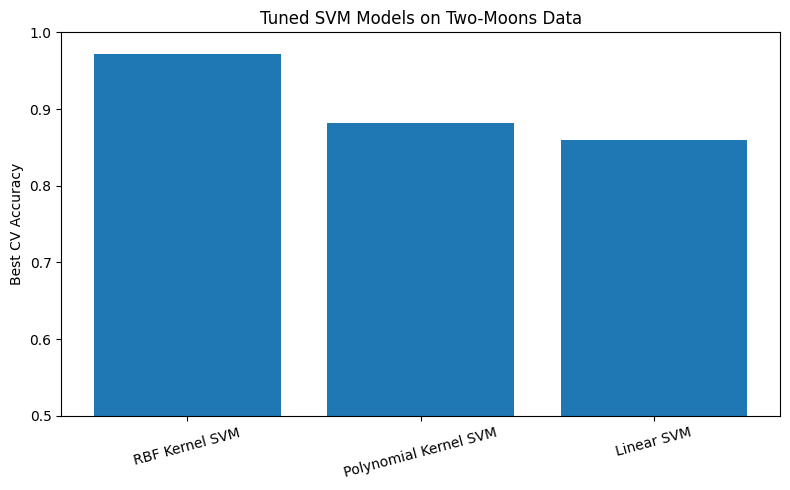

In [10]:
plot_df = search_df.copy()

plt.figure(figsize=(8, 5))
plt.bar(plot_df['Model'], plot_df['Best CV Accuracy'])
plt.ylim(0.5, 1.0)
plt.ylabel('Best CV Accuracy')
plt.title('Tuned SVM Models on Two-Moons Data')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## 10. Final remarks

- The two-moons dataset is nonlinear, so **Linear SVM** usually struggles.
- **RBF Kernel SVM** is often the strongest choice on this type of data.
- **Polynomial Kernel SVM** may work well, but is often more sensitive to parameter settings.
- Cross-validation is more reliable than a single train/test split for model selection.
- Decision boundary plots make the difference between linear and kernel SVM very clear.
